In [1]:
import os

os.makedirs("../csv", exist_ok=True)
os.makedirs("../svg", exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
import pandas as pd
import numpy as np
from scipy.stats import theilslopes
from scipy.stats import gmean


In [3]:
plt.rcParams.update({
    'font.family': 'TeX Gyre Termes',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

In [4]:
TEXTWIDTH_PT = 424.51552
TEXTHEIGHT_PT = 700.50723
PT_PER_INCH = 72.27

FIG_WIDTH = TEXTWIDTH_PT / PT_PER_INCH
FIG_HEIGHT_1 = TEXTHEIGHT_PT / PT_PER_INCH
FIG_HEIGHT_2 = FIG_HEIGHT_1 / 2
FIG_HEIGHT_3 = FIG_HEIGHT_1 / 3
FIG_HEIGHT_4 = FIG_HEIGHT_1 / 4
FIG_HEIGHT_5 = FIG_HEIGHT_1 / 5
FIG_HEIGHT_6 = FIG_HEIGHT_1 / 6
FIG_HEIGHT_7 = FIG_HEIGHT_1 / 7
FIG_HEIGHT_8 = FIG_HEIGHT_1 / 8

In [5]:
ciretrion_x86 = pd.read_csv('../data/criterion_x86.csv')
ciretrion_aarch64 = pd.read_csv('../data/criterion_aarch64.csv')
ciretrion = pd.concat([ciretrion_x86, ciretrion_aarch64], ignore_index=True)
ciretrion

,row_index,benchmark,backend,architecture,function,version,suffix,throughput_num,throughput_type,sample_measured_value,unit,iteration_count
0,0,speck,sse2,x86_64,decrypt,128_256,NaN,2,elements,998407.0,ns,15290
1,1,speck,sse2,x86_64,decrypt,128_256,NaN,2,elements,1988499.0,ns,30580
2,2,speck,sse2,x86_64,decrypt,128_256,NaN,2,elements,2989501.0,ns,45870
3,3,speck,sse2,x86_64,decrypt,128_256,NaN,2,elements,3984812.0,ns,61160
4,4,speck,sse2,x86_64,decrypt,128_256,NaN,2,elements,4936903.0,ns,76450
...,...,...,...,...,...,...,...,...,...,...,...,...
23395,95,speck,neon,aarch64,decrypt,32_64,NaN,8,elements,95058417.0,ns,1011744
23396,96,speck,neon,aarch64,decrypt,32_64,NaN,8,elements,96015000.0,ns,1022283
23397,97,speck,neon,aarch64,decrypt,32_64,NaN,8,elements,97013500.0,ns,1032822
23398,98,speck,neon,aarch64,decrypt,32_64,NaN,8,elements,98150708.0,ns,1043361


In [6]:
speck = ciretrion[ciretrion['benchmark'] == 'speck']
speck = speck.drop(columns=['benchmark', 'suffix', 'unit', 'throughput_type'])
speck['time_per_iter_ns'] = speck['sample_measured_value'] / speck['iteration_count']

speck['keys_per_sec'] = (
        speck['throughput_num'] / (speck['time_per_iter_ns'] / 1e9)
)
speck

,row_index,backend,architecture,function,version,throughput_num,sample_measured_value,iteration_count,time_per_iter_ns,keys_per_sec
0,0,sse2,x86_64,decrypt,128_256,2,998407.0,15290,65.298038,3.062879e+07
1,1,sse2,x86_64,decrypt,128_256,2,1988499.0,30580,65.026128,3.075687e+07
2,2,sse2,x86_64,decrypt,128_256,2,2989501.0,45870,65.173338,3.068740e+07
3,3,sse2,x86_64,decrypt,128_256,2,3984812.0,61160,65.153891,3.069655e+07
4,4,sse2,x86_64,decrypt,128_256,2,4936903.0,76450,64.576887,3.097083e+07
...,...,...,...,...,...,...,...,...,...,...
23395,95,neon,aarch64,decrypt,32_64,8,95058417.0,1011744,93.955009,8.514714e+07
23396,96,neon,aarch64,decrypt,32_64,8,96015000.0,1022283,93.922133,8.517694e+07
23397,97,neon,aarch64,decrypt,32_64,8,97013500.0,1032822,93.930513,8.516934e+07
23398,98,neon,aarch64,decrypt,32_64,8,98150708.0,1043361,94.071666,8.504155e+07


In [7]:
group_cols = ['backend', 'architecture', 'function', 'version']
results = []

for keys, group in speck.groupby(group_cols):
    x = group['iteration_count'].values
    y = group['sample_measured_value'].values

    slope, intercept, ci_low, ci_high = theilslopes(y, x, 0.95)

    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    keys_per_iter = group['throughput_num'].iloc[0]
    keys_per_sec = keys_per_iter / (slope / 1e9)

    results.append({
        **dict(zip(group_cols, keys)),
        'time_per_iter_ns': slope,
        'ci_95_low_ns': ci_low,
        'ci_95_high_ns': ci_high,
        'intercept_ns': intercept,
        'r2': r2,
        'keys_per_sec': keys_per_sec,
        'Mkeys_per_sec': keys_per_sec / 1e6,
    })

speck_reg = pd.DataFrame(results)
speck_reg

,backend,architecture,function,version,time_per_iter_ns,ci_95_low_ns,ci_95_high_ns,intercept_ns,r2,keys_per_sec,Mkeys_per_sec
0,avx2,x86_64,decrypt,128_128,65.710532,65.655374,65.795853,-11286.389717,0.999930,6.087304e+07,60.873042
1,avx2,x86_64,decrypt,128_192,63.717418,63.561172,63.864724,8534.457486,0.999722,6.277718e+07,62.777183
2,avx2,x86_64,decrypt,128_256,65.588616,65.471804,65.697682,-45881.241319,0.999813,6.098619e+07,60.986193
3,avx2,x86_64,decrypt,32_64,38.483529,38.443400,38.525008,532408.567353,0.999577,4.157623e+08,415.762290
4,avx2,x86_64,decrypt,48_72,50.752994,50.749062,50.753132,-119354.039409,0.999974,1.576262e+08,157.626167
...,...,...,...,...,...,...,...,...,...,...,...
175,sse2,x86_64,encrypt_inflight,48_96,32.296376,32.263010,32.305216,1875.105351,0.999510,1.238529e+08,123.852905
176,sse2,x86_64,encrypt_inflight,64_128,32.336628,32.235942,32.472469,182394.577586,0.994057,1.236987e+08,123.698735
177,sse2,x86_64,encrypt_inflight,64_96,26.938330,26.934653,26.949930,-83764.133258,0.986852,1.484873e+08,148.487306
178,sse2,x86_64,encrypt_inflight,96_144,61.584132,61.553458,61.619488,33784.219444,0.999926,3.247590e+07,32.475898


In [8]:
print(f"Min R^2: {speck_reg['r2'].min():.6f}")
print(f"Czy wszystkie > 0.99: {(speck_reg['r2'] > 0.99).all()}")

print(speck_reg[speck_reg['r2'] <= 0.99][['backend', 'architecture', 'backend', 'function', 'version', 'r2']])

Min R^2: 0.875531
Czy wszystkie > 0.99: False
    backend architecture backend          function  version        r2
122  scalar       x86_64  scalar           decrypt  128_256  0.875531
177    sse2       x86_64    sse2  encrypt_inflight    64_96  0.986852


In [9]:
version_order = ['32_64', '48_72', '48_96', '64_96', '64_128', '96_96', '96_144', '128_128', '128_192', '128_256']

def make_speck_pivot(df, backend_order):
    pivot = df.pivot_table(
        index=['backend', 'version'],
        columns='function',
        values='Mkeys_per_sec'
    ).round(2).reset_index()
    pivot.columns.name = None
    pivot['backend'] = pd.Categorical(pivot['backend'], categories=backend_order, ordered=True)
    pivot['version'] = pd.Categorical(pivot['version'], categories=version_order, ordered=True)
    return pivot.sort_values(['backend', 'version']).reset_index(drop=True)

speck_pivot_x86 = make_speck_pivot(
    speck_reg[speck_reg['architecture'] == 'x86_64'],
    ['scalar', 'sse2', 'avx2', 'avx512']
)
speck_pivot_aarch64 = make_speck_pivot(
    speck_reg[speck_reg['architecture'] == 'aarch64'],
    ['scalar', 'neon']
)

In [10]:
speck_pivot_x86

,backend,version,decrypt,encrypt,encrypt_inflight
0,scalar,32_64,37.50,64.10,64.11
1,scalar,48_72,18.04,33.20,37.17
2,scalar,48_96,17.15,31.08,32.02
3,scalar,64_96,28.04,39.11,39.08
4,scalar,64_128,26.95,36.37,35.89
5,scalar,96_96,11.91,24.63,24.78
6,scalar,96_144,12.21,22.38,23.28
7,scalar,128_128,18.18,43.67,44.33
8,scalar,128_192,19.41,37.33,39.65
9,scalar,128_256,20.26,34.40,40.05


In [11]:
speck_pivot_aarch64

,backend,version,decrypt,encrypt,encrypt_inflight
0,scalar,32_64,12.29,21.87,24.13
1,scalar,48_72,12.55,18.60,21.46
2,scalar,48_96,11.87,17.80,20.40
3,scalar,64_96,15.81,29.12,29.18
4,scalar,64_128,15.11,27.89,27.81
5,scalar,96_96,8.56,13.38,15.60
6,scalar,96_144,8.88,13.11,15.40
7,scalar,128_128,11.53,21.99,15.32
8,scalar,128_192,11.15,21.55,21.57
9,scalar,128_256,10.71,20.83,20.77


In [12]:
for pivot, name in [(speck_pivot_x86, 'x86'), (speck_pivot_aarch64, 'aarch64')]:
    out = pivot.copy()
    out['version'] = out['version'].astype(str).str.replace('_', '/', regex=False)
    out.to_csv(f'../csv/speck_pivot_{name}.csv', index=False)

In [13]:
def make_speck_pivot_mean(pivot, backend_order):
    mean = pivot.groupby('backend')[['decrypt', 'encrypt', 'encrypt_inflight']].agg(gmean).reset_index()
    mean['backend'] = pd.Categorical(mean['backend'], categories=backend_order, ordered=True)
    mean = mean.sort_values('backend')
    return mean.set_index('backend')[['decrypt', 'encrypt', 'encrypt_inflight']]

speck_pivot_mean_x86 = make_speck_pivot_mean(speck_pivot_x86, ['scalar', 'sse2', 'avx2', 'avx512'])
speck_pivot_mean_aarch64 = make_speck_pivot_mean(speck_pivot_aarch64, ['scalar', 'neon'])

speck_pivot_mean_x86

,decrypt,encrypt,encrypt_inflight
backend,,,
scalar,19.768581,35.185460,36.627691
sse2,54.141830,68.754645,84.991371
avx2,107.739065,136.662896,136.603186
avx512,162.278107,182.751155,182.494354


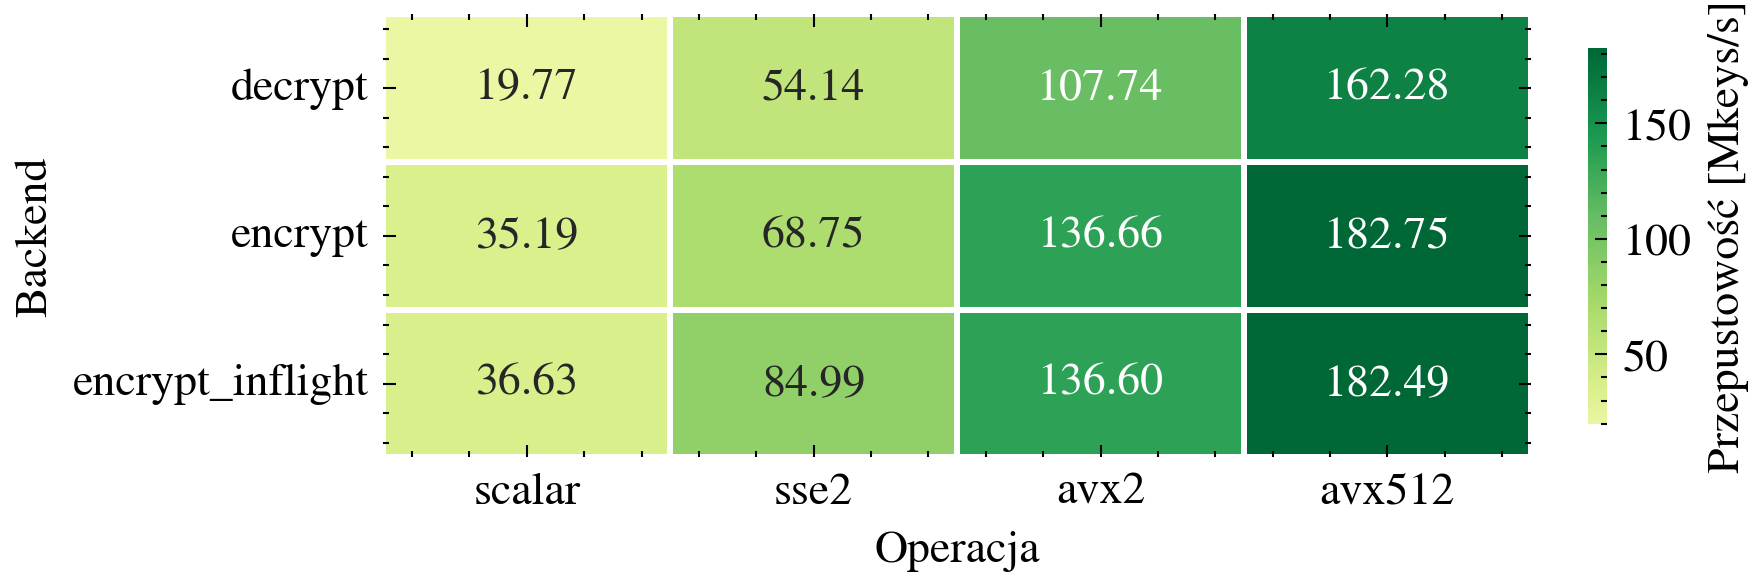

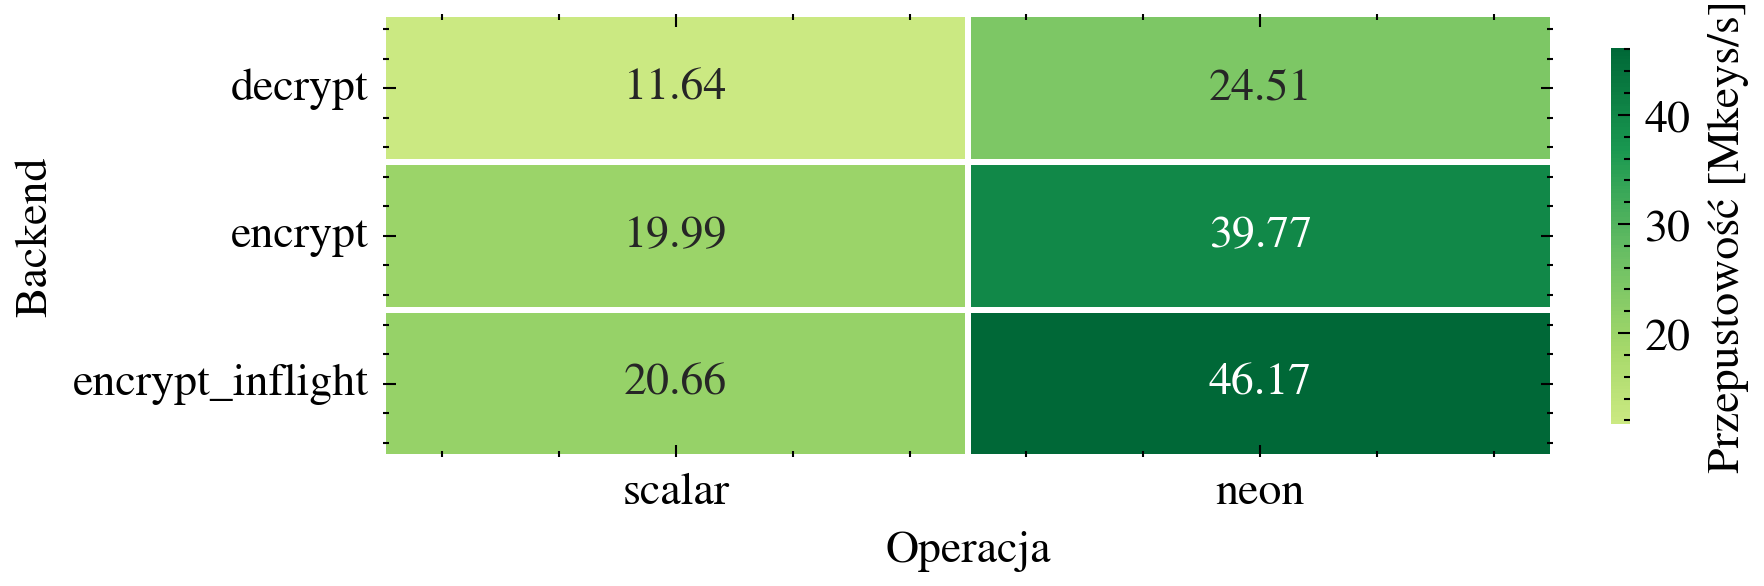

In [14]:
def plot_speck_heatmap(pivot_mean, filename):
    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT_5), layout='constrained')

        sns.heatmap(
            pivot_mean.T,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            annot=True,
            fmt='.2f',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość [Mkeys/s]', 'shrink': 0.85},
        )

        ax.set_xlabel('Operacja')
        ax.set_ylabel('Backend')

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()

plot_speck_heatmap(speck_pivot_mean_x86, 'speck_pivot_backend_heatmap_x86.svg')
plot_speck_heatmap(speck_pivot_mean_aarch64, 'speck_pivot_backend_heatmap_aarch64.svg')

In [15]:
speck_encrypt_inflight = speck_reg[speck_reg['function'] == 'encrypt_inflight']
speck_encrypt_inflight = speck_encrypt_inflight.drop(columns=['function'])
speck_encrypt_inflight

,backend,architecture,version,time_per_iter_ns,ci_95_low_ns,ci_95_high_ns,intercept_ns,r2,keys_per_sec,Mkeys_per_sec
20,avx2,x86_64,128_128,48.693839,48.614950,48.898593,290529.124082,0.999742,8.214592e+07,82.145916
21,avx2,x86_64,128_192,48.158558,47.874213,48.325170,212800.585125,0.999668,8.305897e+07,83.058966
22,avx2,x86_64,128_256,49.852080,49.731386,50.160527,311937.711806,0.999755,8.023737e+07,80.237374
23,avx2,x86_64,32_64,27.889441,27.847283,27.935595,-108570.838925,0.999825,5.736938e+08,573.693817
24,avx2,x86_64,48_72,41.089835,41.071290,41.091487,-57213.022222,0.999997,1.946954e+08,194.695357
25,avx2,x86_64,48_96,42.967950,42.967919,43.001724,52868.106250,0.999997,1.861853e+08,186.185287
26,avx2,x86_64,64_128,36.290037,36.240872,36.345512,14999.842532,0.999859,2.204462e+08,220.446178
27,avx2,x86_64,64_96,34.952896,34.882145,35.026132,258477.457038,0.999456,2.288795e+08,228.879458
28,avx2,x86_64,96_144,62.375961,62.325447,62.392044,304.413690,0.999882,6.412727e+07,64.127269
29,avx2,x86_64,96_96,65.136459,65.116894,65.151808,-10251.479449,0.999980,6.140954e+07,61.409540


In [25]:
def make_speck_backend_speedup(df, backend_order):
    version_order = ['32_64', '48_72', '48_96', '64_96', '64_128', '96_96', '96_144', '128_128', '128_192', '128_256']

    scalar_perf = df[df['backend'] == 'scalar'].set_index('version')['keys_per_sec']
    speedup = df[df['backend'] != 'scalar'].copy()
    speedup['speedup'] = (speedup['keys_per_sec'] / speedup['version'].map(scalar_perf)).round(2)
    speedup = speedup.drop(columns=['time_per_iter_ns', 'ci_95_high_ns', 'ci_95_low_ns', 'intercept_ns', 'r2', 'keys_per_sec', 'Mkeys_per_sec'])

    speedup['backend'] = pd.Categorical(speedup['backend'], categories=backend_order, ordered=True)
    speedup['version'] = pd.Categorical(speedup['version'], categories=version_order, ordered=True)

    speedup = speedup.pivot_table(index='version', columns='backend', values='speedup').reset_index()
    speedup.columns.name = None
    speedup['version'] = speedup['version'].astype(str).str.replace('_', '/', regex=False)
    return speedup.set_index('version')

speck_backend_speedup_x86 = make_speck_backend_speedup(
    speck_encrypt_inflight[speck_encrypt_inflight['architecture'] == 'x86_64'],
    ['sse2', 'avx2', 'avx512']
)
speck_backend_speedup_aarch64 = make_speck_backend_speedup(
    speck_encrypt_inflight[speck_encrypt_inflight['architecture'] == 'aarch64'],
    ['neon']
)

# speck_backend_speedup_x86

speck_backend_speedup = pd.merge(speck_backend_speedup_x86, speck_backend_speedup_aarch64, on='version', how='left')
speck_backend_speedup

,sse2,avx2,avx512,neon
version,,,,
32/64,5.55,8.95,12.05,6.77
48/72,3.32,5.24,5.69,2.59
48/96,3.87,5.81,6.22,2.57
64/96,3.80,5.86,8.13,2.22
64/128,3.45,6.14,8.43,2.22
96/96,1.26,2.48,3.51,1.20
96/144,1.39,2.75,3.94,1.24
128/128,1.28,1.85,2.72,2.70
128/192,1.53,2.09,2.99,1.87


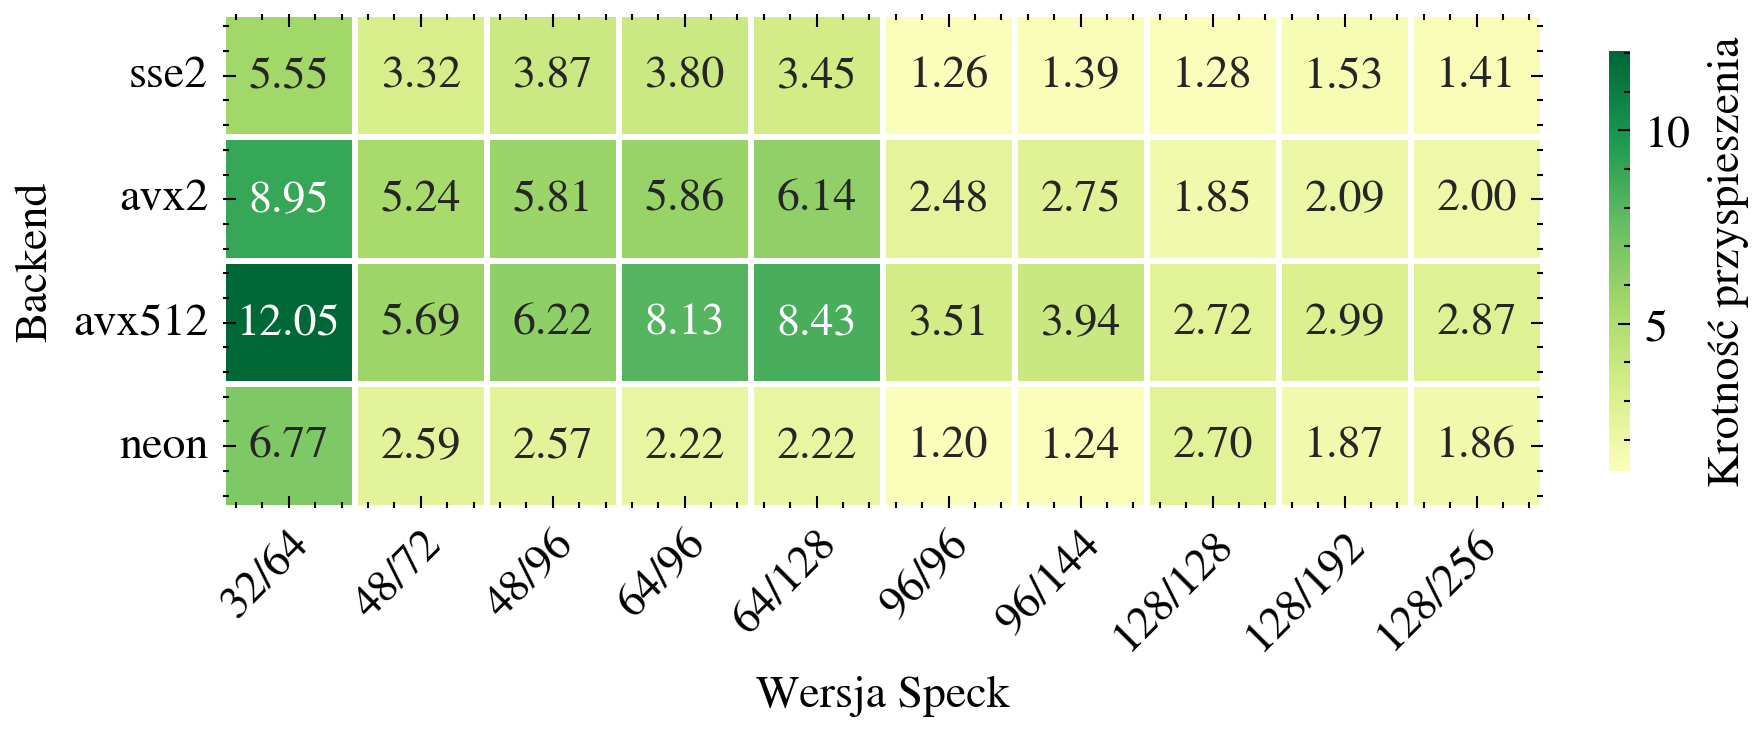

In [26]:
def plot_speck_backend_speedup(speedup, filename, fig_height, label):
    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, fig_height), layout='constrained')

        sns.heatmap(
            speedup.T,
            ax=ax,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=1,
            linewidths=1.0,
            cbar_kws={'label': label, 'shrink': 0.85},
        )
        ax.set_xlabel('Wersja Speck')
        ax.set_ylabel('Backend')

        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()

plot_speck_backend_speedup(speck_backend_speedup, 'speck_backend_speedup.svg', FIG_HEIGHT_4, 'Krotność przyspieszenia')

In [ ]:
def parse_turbostat(filepath):
    samples = []
    current = {}

    with open(filepath) as f:
        for line in f:
            parts = line.split()
            if not parts:
                continue

            if parts[0] == "CPU":
                if current:
                    samples.append(current)
                continue

            cpu = "system" if parts[0] == "-" else f"cpu{parts[0]}"
            current[f"{cpu}"] = int(parts[2])
            if len(parts) > 3 and cpu == "system":
                current[f"{cpu}_pkg_watt"] = float(parts[3])

        if current:
            samples.append(current)

    return pd.DataFrame(samples)

In [ ]:
bench_turbostat = parse_turbostat("../data/turbostat-bench.txt")
cpu_cols = sorted(
    [c for c in bench_turbostat.columns if c.startswith("cpu")],
    key=lambda x: int(x.replace("cpu", "").split("_")[0])
)
other_cols = [c for c in bench_turbostat.columns if not c.startswith("cpu")]

bench_turbostat = bench_turbostat[other_cols + cpu_cols]
bench_turbostat

In [ ]:
cols_to_check = cpu_cols + ["system_pkg_watt"]

results = {}
for c in cols_to_check:
    y = bench_turbostat[c].dropna().values
    x = np.arange(len(y))
    slope, intercept, lo, hi = theilslopes(y, x, 0.95)
    results[c] = {"slope_per_sample": slope, "ci_low": lo, "ci_high": hi, "intercept": intercept}

bench_turbostat_trends = pd.DataFrame(results).T
bench_turbostat_trends

In [ ]:
system_turbostat = parse_turbostat("../data/turbostat-system.txt")
cpu_cols = sorted(
    [c for c in system_turbostat.columns if c.startswith("cpu")],
    key=lambda x: int(x.replace("cpu", "").split("_")[0])
)
other_cols = [c for c in system_turbostat.columns if not c.startswith("cpu")]

system_turbostat = system_turbostat[other_cols + cpu_cols]
system_turbostat

In [ ]:
cols_to_check = cpu_cols + ["system_pkg_watt"]

results = {}
for c in cols_to_check:
    y = system_turbostat[c].dropna().values
    x = np.arange(len(y))
    slope, intercept, lo, hi = theilslopes(y, x, 0.95)
    results[c] = {"slope_per_sample": slope, "ci_low": lo, "ci_high": hi, "intercept": intercept}

system_turbostat_trends = pd.DataFrame(results).T
system_turbostat_trends

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


def prepare_data(df, cpu_cols):
    df_freq = df[cpu_cols].copy()
    df_freq["sample"] = np.arange(len(df_freq))
    df_freq_long = df_freq.melt(
        id_vars="sample", var_name="CPU", value_name="freq"
    )
    df_watt = pd.DataFrame({
        "sample": np.arange(len(df)),
        "watt": df["system_pkg_watt"].values,
    })
    return df_freq_long, df_watt


def plot_turbostat(df_raw, trends_df, cpu_cols, filename):
    df_freq_long, df_watt = prepare_data(df_raw, cpu_cols)

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(FIG_WIDTH / 2, FIG_HEIGHT_3), layout='constrained', sharex=True,
            gridspec_kw={"height_ratios": [2, 1]},
        )

        sns.lineplot(
            data=df_freq_long, x="sample", y="freq", hue="CPU",
            palette=["#4C9BE8"] * len(cpu_cols),
            linewidth=0.7, alpha=0.25, legend=False, ax=ax1,
        )

        median_freq = df_raw[cpu_cols].median(axis=1)
        sns.lineplot(
            x=np.arange(len(median_freq)), y=median_freq.values,
            color="#1F4E79", linewidth=1.6,
            label="Mediana rdzeni", ax=ax1,
        )

        freq_min = trends_df.loc[cpu_cols, "intercept"].min()
        freq_max = trends_df.loc[cpu_cols, "intercept"].max()
        ax1.set_ylim(np.floor(freq_min / 100) * 100, np.ceil(freq_max / 100) * 100)
        ax1.set_ylabel("Częstotliwość [MHz]")
        ax1.set_xlabel("")
        ax1.legend(loc="lower right", frameon=False)

        sns.lineplot(
            data=df_watt, x="sample", y="watt",
            color="#C0392B", linewidth=1.0, ax=ax2,
        )
        ax2.fill_between(
            df_watt["sample"], 0, df_watt["watt"],
            color="#C0392B", alpha=0.12,
        )

        watt_max = df_watt["watt"].max()
        ax2.set_ylim(0, np.ceil(watt_max / 100) * 100)
        ax2.set_ylabel("Pobór mocy [W]")
        ax2.set_xlabel("Numer próbki")

        plt.savefig(f'../svg/{filename}.svg', facecolor='white')
        plt.show()


plot_turbostat(bench_turbostat, bench_turbostat_trends,
               cpu_cols, "turbostat_bench")
plot_turbostat(system_turbostat, system_turbostat_trends,
               cpu_cols, "turbostat_system")

In [ ]:
def print_turbostat_summary(df_raw, trends_df, cpu_cols, label):
    freq_min = trends_df.loc[cpu_cols, "intercept"].min()
    freq_max = trends_df.loc[cpu_cols, "intercept"].max()
    watt_med = trends_df.loc["system_pkg_watt", "intercept"]

    freq_slopes = trends_df.loc[cpu_cols, "slope_per_sample"]
    freq_slope_min = freq_slopes.min()
    freq_slope_max = freq_slopes.max()

    watt_slope = trends_df.loc["system_pkg_watt", "slope_per_sample"]
    watt_ci_low = trends_df.loc["system_pkg_watt", "ci_low"]
    watt_ci_high = trends_df.loc["system_pkg_watt", "ci_high"]

    print(f"=== {label} ===")
    print(f"Częstotliwość:")
    print(f"  Theil–Sen β ∈ [{freq_slope_min:.4f}; {freq_slope_max:.4f}] MHz/próbkę")
    print(f"  Mediany per rdzeń: {freq_min:.0f}–{freq_max:.0f} MHz")
    print(f"Pobór mocy CPU:")
    print(f"  Theil–Sen β = {watt_slope:.4f} W/próbkę  "
          f"(95% CI: [{watt_ci_low:.4f}; {watt_ci_high:.4f}])")
    print(f"  Mediana = {watt_med:.2f} W")
    print()


print_turbostat_summary(bench_turbostat, bench_turbostat_trends,
                        cpu_cols, "Bench")
print_turbostat_summary(system_turbostat, system_turbostat_trends,
                        cpu_cols, "System")

In [ ]:
scalar_turbostat = parse_turbostat("../data/turbostat-search-Scalar.txt")
cpu_cols = sorted(
    [c for c in scalar_turbostat.columns if c.startswith("cpu")],
    key=lambda x: int(x.replace("cpu", "").split("_")[0])
)
other_cols = [c for c in scalar_turbostat.columns if not c.startswith("cpu")]

scalar_turbostat = scalar_turbostat[other_cols + cpu_cols]
scalar_turbostat

In [ ]:
sse2_turbostat = parse_turbostat("../data/turbostat-search-Sse2.txt")
cpu_cols = sorted(
    [c for c in sse2_turbostat.columns if c.startswith("cpu")],
    key=lambda x: int(x.replace("cpu", "").split("_")[0])
)
other_cols = [c for c in sse2_turbostat.columns if not c.startswith("cpu")]

sse2_turbostat = sse2_turbostat[other_cols + cpu_cols]
sse2_turbostat

In [ ]:
avx2_turbostat = parse_turbostat("../data/turbostat-search-Avx2.txt")
cpu_cols = sorted(
    [c for c in avx2_turbostat.columns if c.startswith("cpu")],
    key=lambda x: int(x.replace("cpu", "").split("_")[0])
)
other_cols = [c for c in avx2_turbostat.columns if not c.startswith("cpu")]

avx2_turbostat = avx2_turbostat[other_cols + cpu_cols]
avx2_turbostat

In [ ]:
avx512_turbostat = parse_turbostat("../data/turbostat-search-Avx512.txt")
cpu_cols = sorted(
    [c for c in avx512_turbostat.columns if c.startswith("cpu")],
    key=lambda x: int(x.replace("cpu", "").split("_")[0])
)
other_cols = [c for c in avx512_turbostat.columns if not c.startswith("cpu")]

avx512_turbostat = avx512_turbostat[other_cols + cpu_cols]
avx512_turbostat

In [ ]:
backends = {
    "Scalar": scalar_turbostat,
    "SSE2": sse2_turbostat,
    "AVX2": avx2_turbostat,
    "AVX512": avx512_turbostat,
}

turbostat_compare = pd.concat(
    [
        df[["system", "system_pkg_watt"]]
        .rename(columns={"system": "freq_mhz", "system_pkg_watt": "pkg_watt"})
        .assign(backend=name)
        for name, df in backends.items()
    ],
    ignore_index=True,
)

backend_order = ["Scalar", "SSE2", "AVX2", "AVX512"]

with plt.style.context(['science', 'no-latex', 'bright']):
    fig, ax = plt.subplots(figsize=(FIG_WIDTH / 2, FIG_HEIGHT_4), layout='constrained')
    sns.stripplot(
        data=turbostat_compare, x="backend", y="freq_mhz",
        order=backend_order, hue="backend",
        jitter=0.2, size=9, alpha=0.9, edgecolor="none",
        legend=False, ax=ax,
    )
    freq_min = turbostat_compare["freq_mhz"].min()
    freq_max = turbostat_compare["freq_mhz"].max()
    ax.set_ylim(np.floor(freq_min / 100) * 100, np.ceil(freq_max / 100) * 100)
    ax.set_xlabel("Backend")
    ax.set_ylabel("Częstotliwość Bzy [MHz]")
    plt.savefig('../svg/turbostat_freq_compare.svg', facecolor='white')
    plt.show()

    fig, ax = plt.subplots(figsize=(FIG_WIDTH / 2, FIG_HEIGHT_4), layout='constrained')
    sns.stripplot(
        data=turbostat_compare, x="backend", y="pkg_watt",
        order=backend_order, hue="backend",
        jitter=0.2, size=9, alpha=0.9, edgecolor="none",
        legend=False, ax=ax,
    )
    watt_min = turbostat_compare["pkg_watt"].min()
    watt_max = turbostat_compare["pkg_watt"].max()
    ax.set_ylim(np.floor((watt_min - 10) / 5) * 5, np.ceil((watt_max + 10) / 5) * 5)
    ax.set_xlabel("Backend")
    ax.set_ylabel("Pobór mocy pakietu [W]")
    plt.savefig('../svg/turbostat_power_compare.svg', facecolor='white')
    plt.show()

In [ ]:
f = turbostat_compare["freq_mhz"]
mean = f.mean()
fmin, fmax = f.min(), f.max()
dev_pct = max(abs(fmin - mean), abs(fmax - mean)) / mean * 100

print(f"Częstotliwość między backendami: {fmin:.0f}–{fmax:.0f} MHz "
      f"(rozrzut {fmax - fmin:.0f} MHz)")
print(f"Średnia: {mean:.0f} MHz, maks. odchył od średniej: {dev_pct:.2f}%")

In [ ]:
p = turbostat_compare["pkg_watt"]
mean = p.mean()
pmin, pmax = p.min(), p.max()
dev_pct = max(abs(pmin - mean), abs(pmax - mean)) / mean * 100

print(f"Pobór mocy między backendami: {pmin:.2f}–{pmax:.2f} W "
      f"(rozrzut {pmax - pmin:.2f} W)")
print(f"Średnia: {mean:.2f} W, maks. odchył od średniej: {dev_pct:.2f}%")

In [ ]:
engine = ciretrion[ciretrion['benchmark'] == 'engine']
engine = engine.drop(columns=['benchmark', 'unit', 'throughput_type', 'function'])
engine['time_per_iter_ns'] = engine['sample_measured_value'] / engine['iteration_count']

engine['keys_per_sec'] = (
        engine['throughput_num'] / (engine['time_per_iter_ns'] / 1e9)
)
engine

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import bootstrap

group_cols = ['backend', 'architecture', 'version', 'suffix']


def analyze_group(group):
    t = (group['sample_measured_value'] / group['iteration_count']).to_numpy()
    n_keys = group['throughput_num'].iloc[0]

    median_ns = np.median(t)
    mad_ns = np.median(np.abs(t - median_ns))
    mad_sigma = 1.4826 * mad_ns

    res_median = bootstrap(
        (t,), np.median,
        n_resamples=10_000,
        confidence_level=0.95,
        method='BCa',
        random_state=0,
    )
    ci_low, ci_high = res_median.confidence_interval

    mkeys_per_sec = n_keys / (median_ns / 1e9) / 1e6
    mkeys_low = n_keys / (ci_high / 1e9) / 1e6
    mkeys_high = n_keys / (ci_low / 1e9) / 1e6

    rel_mad = mad_ns / median_ns
    p05, p95 = np.percentile(t, [5, 95])
    spread = (p95 - p05) / median_ns

    return pd.Series({
        'n_samples': len(t),
        'median_ns': median_ns,
        'ci95_low_ns': ci_low,
        'ci95_high_ns': ci_high,
        'mad_ns': mad_ns,
        'mad_sigma_ns': mad_sigma,
        'rel_mad': rel_mad,
        'spread_p05_p95': spread,
        'Mkeys_per_sec': mkeys_per_sec,
        'Mkeys_per_sec_ci_low': mkeys_low,
        'Mkeys_per_sec_ci_high': mkeys_high,
    })


engine_stats = (
    engine
    .groupby(group_cols)
    .apply(analyze_group, include_groups=False)
    .reset_index()
)
print(engine_stats)

In [ ]:
def make_engine_pivot(df, backend_order):
    pivot = (
        df.pivot_table(
            index=['backend', 'version'],
            columns='suffix',
            values='Mkeys_per_sec',
        )
        .rename(columns={1.0: '1', 2.0: '2', 3.0: '3'})
    ).round(2).reset_index()
    pivot.columns.name = None

    version_order = ['32_64', '48_72', '48_96', '64_96', '64_128', '96_96', '96_144', '128_128', '128_192', '128_256']
    pivot['backend'] = pd.Categorical(pivot['backend'], categories=backend_order, ordered=True)
    pivot['version'] = pd.Categorical(pivot['version'], categories=version_order, ordered=True)
    return pivot.sort_values(['backend', 'version']).reset_index(drop=True)

engine_pivot_x86 = make_engine_pivot(
    engine_stats[engine_stats['architecture'] == 'x86_64'],
    ['scalar', 'sse2', 'avx2', 'avx512']
)
engine_pivot_aarch64 = make_engine_pivot(
    engine_stats[engine_stats['architecture'] == 'aarch64'],
    ['scalar', 'neon']
)

engine_pivot_x86

In [ ]:
for pivot, name in [(engine_pivot_x86, 'x86'), (engine_pivot_aarch64, 'aarch64')]:
    out = pivot.copy()
    out['version'] = out['version'].astype(str).str.replace('_', '/', regex=False)
    out.to_csv(f'../csv/engine_pivot_{name}.csv', index=False)

In [ ]:
def make_engine_pivot_mean(pivot, backend_order):
    mean = pivot.groupby('backend')[['1', '2', '3']].agg(gmean).reset_index()
    mean['backend'] = pd.Categorical(mean['backend'], categories=backend_order, ordered=True)
    mean = mean.sort_values('backend')
    return mean.set_index('backend')[['1', '2', '3']]

engine_pivot_mean_x86 = make_engine_pivot_mean(engine_pivot_x86, ['scalar', 'sse2', 'avx2', 'avx512'])
engine_pivot_mean_aarch64 = make_engine_pivot_mean(engine_pivot_aarch64, ['scalar', 'neon'])

engine_pivot_mean_x86

In [ ]:
def plot_engine_heatmap(pivot_mean, filename, width):
    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(width, FIG_HEIGHT_7), layout='constrained')

        sns.heatmap(
            pivot_mean.T,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            annot=True,
            fmt='.2f',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość\n[Mkeys/s]', 'shrink': 0.85},
        )

        ax.set_xlabel('Backend')
        ax.set_ylabel('Sufiks')

        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()

plot_engine_heatmap(engine_pivot_mean_x86, 'engine_pivot_backend_heatmap_x86.svg', FIG_WIDTH * 0.615)
plot_engine_heatmap(engine_pivot_mean_aarch64, 'engine_pivot_backend_heatmap_aarch64.svg', FIG_WIDTH * 0.385)

In [ ]:
def make_engine_single_backend_pivot(df, architecture, backend):
    version_order = ['32_64', '48_72', '48_96', '64_96', '64_128',
                     '96_96', '96_144', '128_128', '128_192', '128_256']

    pivot = (
        df[(df['architecture'] == architecture) & (df['backend'] == backend)]
        .pivot_table(
            index=['backend', 'version'],
            columns='suffix',
            values='Mkeys_per_sec',
        )
        .rename(columns={1.0: '1', 2.0: '2', 3.0: '3'})
    ).round(2).reset_index()

    pivot.columns.name = None
    pivot['version'] = pd.Categorical(pivot['version'], categories=version_order, ordered=True)
    pivot = pivot.sort_values('version').reset_index(drop=True)
    pivot['version'] = pivot['version'].astype(str).str.replace('_', '/', regex=False)
    return pivot.set_index('version')[['1', '2', '3']]

engine_pivot_avx512 = make_engine_single_backend_pivot(engine_stats, 'x86_64', 'avx512')
engine_pivot_neon   = make_engine_single_backend_pivot(engine_stats, 'aarch64', 'neon')

print(engine_pivot_avx512)


In [ ]:
def plot_engine_single_backend_heatmap(pivot, filename):
    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT_5), layout='constrained')

        sns.heatmap(
            pivot.T,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            annot=True,
            fmt='.1f',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość\n[Mkeys/s]', 'shrink': 0.85},
        )

        ax.set_xlabel('Backend')
        ax.set_ylabel('Wartość sufiksu')

        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()

plot_engine_single_backend_heatmap(engine_pivot_avx512, 'engine_pivot_backend_avx512_heatmap.svg')
plot_engine_single_backend_heatmap(engine_pivot_neon,   'engine_pivot_backend_neon_heatmap.svg')
